In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import os

import cleaning as clean

In [10]:
def find_gene(df, gene):
    return df[df["HGVSc"] == gene]

---
Load Datasets

---

In [85]:
crc_data = os.path.abspath("../data/tcga_data2.csv")
crc_df = pd.read_csv(crc_data, sep = '\t', low_memory = False)
# crc_df.head(1)

In [84]:
lung_data = os.path.abspath("../data/lung_data.csv")
lung_df = pd.read_csv(lung_data, low_memory = False)
# lung_df.head(1)

In [83]:
kidney_data = os.path.abspath("../data/kidney_data.csv")
kidney_df = pd.read_csv(kidney_data, low_memory = False)
# kidney_df.head(1)

In [82]:
brain_data = os.path.abspath("../data/brain_data.csv")
brain_df = pd.read_csv(brain_data, low_memory = False)
# brain_df.head(1)

In [81]:
breast_data = os.path.abspath("../data/breast_data.csv")
breast_df = pd.read_csv(brain_data, low_memory = False)
# breast_df.head(1)

In [80]:
pancreas_data = os.path.abspath("../data/pancreatic_data.csv")
pancreas_df = pd.read_csv(pancreas_data, low_memory = False)
# pancreas_df.head(1)

---
Clean Data 

---

In [5]:
relevant = ["Gene", "Sample ID", "Cancer Type Detailed", "Mutation Type", "Variant Type", "HGVSc", "MS", 
        "Protein Change", "Functional Impact"]

In [79]:
clean_crc = clean.clean_data(crc_df, relevant_cols = relevant, early_age = 50)
# clean_crc.head(1)

In [78]:
clean_lungs = clean.clean_data(lung_df, relevant_cols = relevant, early_age = 50)
# clean_lungs.head(1)

In [77]:
clean_kidney = clean.clean_data(kidney_df, relevant_cols = relevant, early_age = 50)
# clean_kidney.head(1)

In [76]:
clean_brain = clean.clean_data(brain_df, relevant_cols = relevant, early_age = 50)
clean_brain = clean_brain[clean_brain["Age"]<=120]
# clean_brain.head(1)

In [75]:
clean_breast = clean.clean_data(breast_df, relevant_cols = relevant, early_age = 50)
clean_breast = clean_breast[clean_breast["Age"]<=120]
# clean_breast.head(1)

In [74]:
clean_pancreas = clean.clean_data(pancreas_df, relevant_cols = relevant, early_age = 50)
# clean_pancreas.head(1)

---
Check that the two datasets do not contain the mutation at all

---

In [63]:
print(find_gene(clean_kidney, "ENST00000257430.4:c.835-8A>G").shape)
print(find_gene(clean_lungs, "ENST00000257430.4:c.835-8A>G").shape)
print(find_gene(clean_brain, "ENST00000257430.4:c.835-8A>G").shape)
print(find_gene(clean_breast, "ENST00000257430.4:c.835-8A>G").shape)
print(find_gene(clean_pancreas, "ENST00000257430.4:c.835-8A>G").shape)

(0, 11)
(0, 11)
(0, 11)
(0, 11)
(0, 11)


---

Check size of datasets

---

In [65]:
print(clean_kidney.shape)
print(clean_lungs.shape)
print(clean_brain.shape)
print(clean_breast.shape)
print(clean_pancreas.shape)
# KIDNEYS ONLY HAS 35 ENTRIES -- TOO SMALL?

(35, 11)
(290, 11)
(23, 11)
(25, 11)
(54, 11)


---
Plot Distributions

---

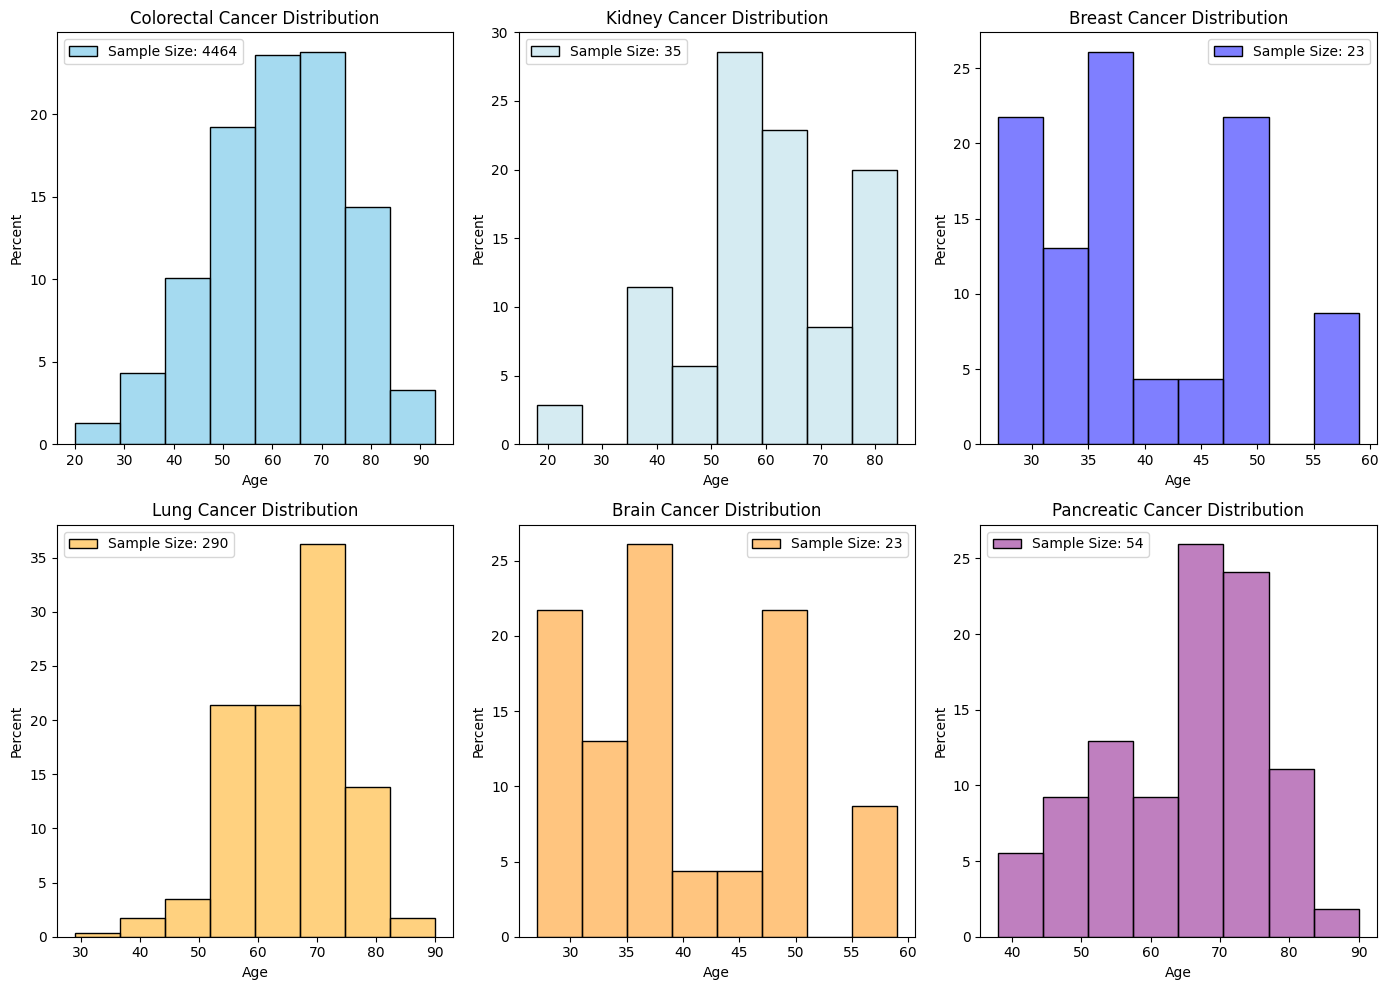

In [89]:
fig, ax = plt.subplots(2, 3, figsize = (14, 10))

sns.histplot(clean_crc["Age"], stat = "percent", color = 'skyblue', bins = 8, ax = ax[0,0], label = f"Sample Size: {clean_crc.shape[0]}")
ax[0,0].set_title("Colorectal Cancer Distribution")
ax[0,0].legend()

sns.histplot(clean_lungs["Age"], stat = "percent", color = 'orange', bins = 8, alpha =0.5, ax = ax[1,0], label = f"Sample Size: {clean_lungs.shape[0]}")
ax[1,0].set_title("Lung Cancer Distribution")
ax[1,0].legend()

sns.histplot(clean_breast["Age"], stat = "percent", color = 'blue', bins = 8, alpha =0.5, ax = ax[0,2], label = f"Sample Size: {clean_breast.shape[0]}")
ax[0,2].set_title("Breast Cancer Distribution")
ax[0,2].legend()

sns.histplot(clean_kidney["Age"], stat = "percent", color = 'lightblue', bins = 8, alpha =0.5, ax = ax[0,1], label = f"Sample Size: {clean_kidney.shape[0]}")
ax[0,1].set_title("Kidney Cancer Distribution")
ax[0,1].legend()

sns.histplot(clean_brain["Age"], stat = "percent", color = 'darkorange', bins = 8, alpha =0.5, ax = ax[1,1], label = f"Sample Size: {clean_brain.shape[0]}")
ax[1,1].set_title("Brain Cancer Distribution")
ax[1,1].legend()

sns.histplot(clean_pancreas["Age"], stat = "percent", color = 'purple', bins = 8, alpha =0.5, ax = ax[1,2], label = f"Sample Size: {clean_pancreas.shape[0]}")
ax[1,2].set_title("Pancreatic Cancer Distribution")
ax[1,2].legend()

plt.tight_layout()
plt.show()